<a href="https://colab.research.google.com/github/Cr1ss4nB/Curso-ONE-Alura-AgentesIA/blob/main/fundamentos_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clase 1:**

## Aprendizaje Supervisado - Clasificación

In [ ]:
# Paso 1: Importar las bibliotecas necesarias
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Paso 2: Cargar el dataset Iris
iris = load_iris()
X = iris.data   # Caracteristicas (largo y ancho de pétalos y sépalos)
y = iris.target # Rótulos (especies de flores)

# Paso 3: Dividir los datos para entrenamiento y para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Paso 4: Entrenar el modelo
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Paso 5: Realizar previsiones y evaluar el modelo
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy * 100:.2f}%")

Exactitud del modelo: 100.00%


In [ ]:
# Paso 1: Importar las bibliotecas necesarias
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import pandas as pd

# Paso 2: Cargar y preparar el dataset Iris
dataset = load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

# Paso 3: Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['species']))

# Paso 4: Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['species'], test_size=0.3, random_state=42)

# Paso 5: Entrenar y evaluar el árbol de decisión
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
tree_accuracy = accuracy_score(y_test, tree_model.predict(X_test))
print(f"Exactitud del modelo de Árbol de Decisión: {tree_accuracy * 100:.2f}%")

# Paso 6: Entrenar y evaluar el KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_accuracy = accuracy_score(y_test, knn_model.predict(X_test))
print(f"Exactitud del modelo KNN: {knn_accuracy * 100:.2f}%")

Exactitud del modelo de Árbol de Decisión: 100.00%
Exactitud del modelo KNN: 100.00%


## **Aprendizaje Supervisado - Regresión**


> Añadir blockquote



Coeficiente angular (b1): 19.43
Intercepto (b0): 514.29

Métricas de Evaluación:
R^2 en datos de prueba: 0.94
Error Medio Absoluto (MAE): 7.39
Raíz del Error Cuadrático Medio (RMSE): 9.34

Promedio de los puntajes de la validación cruzada: 0.95


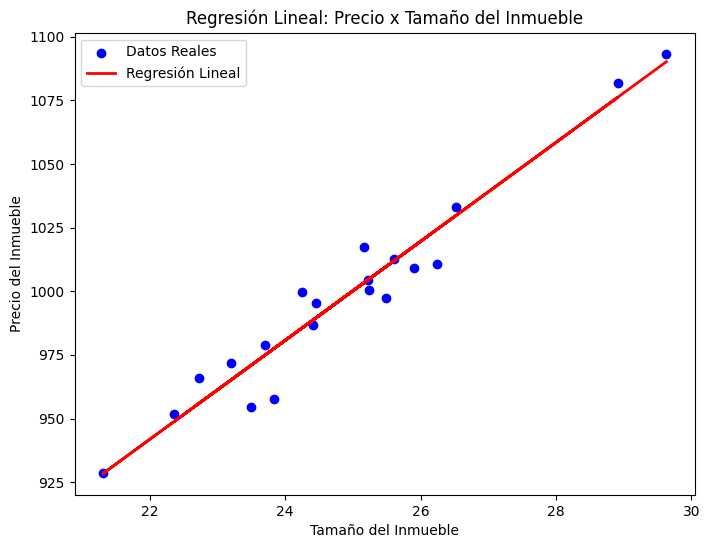

In [ ]:
# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Creando un conjunto de datos simulados
np.random.seed(42)
X = 2.5 * np.random.randn(100, 1) + 25 # Tamaño del inmueble (m2)
y = 500 + (X * 20) + np.random.randn(100, 1) * 10 # Precio del inmueble (miles de dólares)

# Definiendo features (independientes) y labels (dependientes)
features = X
labels = y

# Dividiendo los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Creando y entrenando el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Modelo de Regresión Lineal
# Y = A X + B
# Y -> Variable de salida
# X -> Tamaño del inmueble
# A y B son los coeficientes

# Coeficientes de Regresión
print(f"Coeficiente angular (b1): {model.coef_[0][0]:.2f}")
print (f"Intercepto (b0): {model.intercept_[0]:.2f}")

# Predicciones con los datos de prueba
y_pred = model.predict(X_test)

# Indicadores de la Evaluación del modelo con los datos de prueba
# R^2 Ajuste de los datos al modelo
r2 = r2_score(y_test, y_pred)
# MAE (Error Medio Absoluto)
mae= mean_absolute_error(y_test, y_pred)
# RMSE (Raíz del error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nMétricas de Evaluación:")
print(f"R^2 en datos de prueba: {r2:.2f}")
print(f"Error Medio Absoluto (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")

# Evaluación cruzada
cv_scores = cross_val_score(model, features, labels, cv=5, scoring='r2')
print(f"\nPromedio de los puntajes de la validación cruzada: {cv_scores.mean():.2f}")

# Gráfico de la recta de Regresi+on
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos Reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regresión Lineal')
plt.xlabel("Tamaño del Inmueble")
plt.ylabel("Precio del Inmueble")
plt.title("Regresión Lineal: Precio x Tamaño del Inmueble")
plt.legend()
plt.show()

# **Clase 2**

## **Ejemplos de Clasificación y Regresión**

In [ ]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Ver las primeras 5 filas de los datos
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape

(20640, 9)

## **Ejemplo Regresión**

### Modelo de Regresión Lineal

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Cargar el conjunto de datos
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Dividir los datos en datos de entrenamiento y de prueba
X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar la previsión
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Exhibir las métricas
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

# Visualización de los resultados
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)  # Línea de referencia
plt.xlabel("Valores Reales")
plt.ylabel("Valores Previstos")
plt.title("Regresión Lineal: Valores Reales vs. Previstos")
plt.show()

In [ ]:
from sklearn.datasets import load_diabetes

# Cargar los datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Ver las primeras 5 filas de los datos
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
df.shape

(442, 10)

## **Ejemplo Clasificación**

### Modelo de Regresión Logística

Exactitud del Modelo: 80.45%


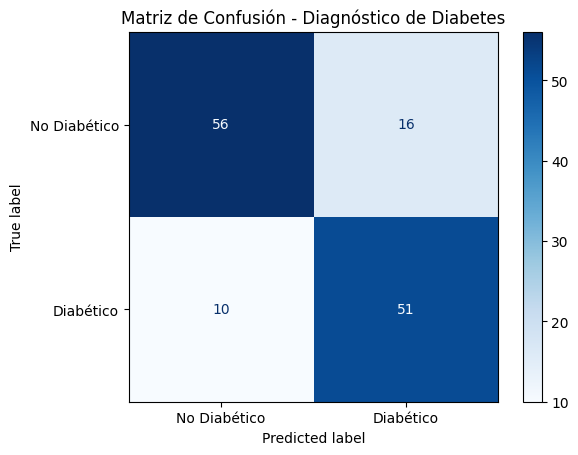

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cargar los datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['OUTCOME'] = diabetes.target

# Transformar la variable target en binaria (clasificación)
df['OUTCOME'] = (df['OUTCOME'] > df['OUTCOME'].median()).astype(int)  # 1 cuando es superior a la mediana, y 0 cuando es inferior

# Dividir los datos en datos de entrenamiento y datos de prueba
X = df.drop('OUTCOME', axis=1)
y = df['OUTCOME']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar el modelo
model = LogisticRegression(max_iter=1000)  # Aumentando las iteraciones para evitar warnings
model.fit(X_train, y_train)

# Realizar la Previsión
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del Modelo: {accuracy * 100:.2f}%")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabético', 'Diabético'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Diagnóstico de Diabetes")
plt.show()

***Para leer la matriz de confusión:***

Aquí significa que de la totalidad de 72 personas en la primera fila se diagnosticaron como NO diabéticos correctamente a 56 personas pero a 16 personas les dijeron que eran diabéticas cuando no era así.

En caso de la segunda fila de las 61 personas analizadas, 51 personas fueron correctamente diagnoticadas con diabetes pero las 10 restantes fueron erroneamente diagnosticadas con diabetes.

### **Búsqueda en cuadrícula**

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Cargar dataset
X, y = fetch_california_housing(return_X_y=True)

# Dividir en datos de entrenamiento y datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Definir los hiperparámetros para optimizarlos
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#max_depth -> profundidad máxima del árbol de decisión
#'min_samples_split' -> nº mínimo de muestras para dividir el nodo
#'min_samples_leaf' -> nº mínimo de muestras por hoja

# Aplicar GridSearch para encontrar los mejores hiperparámetros
grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

#GridSearch -> Realiza la búsqueda de los mejores hiperparámetros combinando todos los valores de hiperparámetros
# Métrica de evaluación -> Error Cuadrático Medio Negativo
print(f"Mejores parámetros: {grid_search.best_params_}")

Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


### **Regresor de Bosques Aleatorios (Random Forest Regressor)**

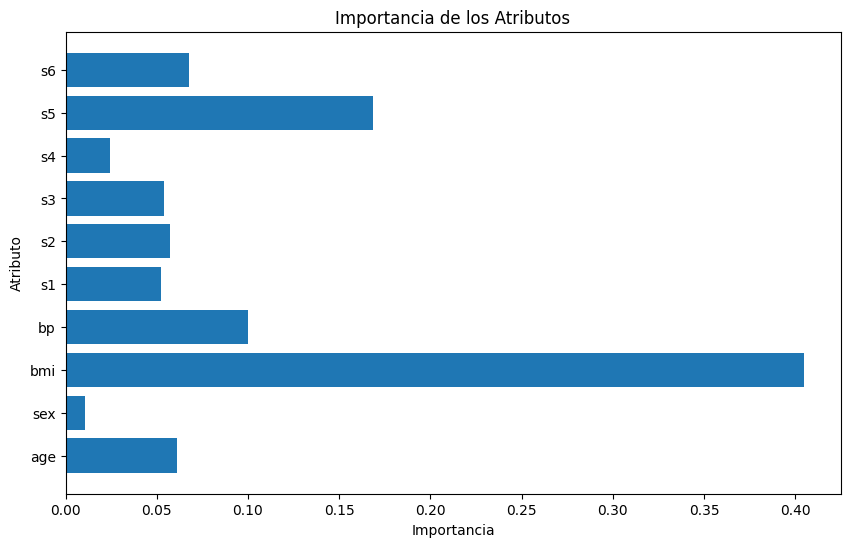

In [ ]:
# Importar bibliotecas
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Cargar el dataset Diabetes
diabetes = load_diabetes()
X = diabetes.data  # Variables independientes
y = diabetes.target  # Variable dependiente

# Dividir los datos para entrenamiento y para prueba (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Obtener la importancia de los atributos
importances = model.feature_importances_
feature_names = diabetes.feature_names

# Crear un gráfico de barras para visualizar la importancia de los atributos
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.title("Importancia de los Atributos")
plt.xlabel("Importancia")
plt.ylabel("Atributo")
plt.show()

## **Combinación de Métodos**

- Métodos Ensemble.
- Bagging / Boosting

Se importa el Random Forest Regressor y Gradient Boosting Regressor.

Random Forest - MSE: 0.29, R²: 0.78
Gradient Boosting - MSE: 0.24, R²: 0.82


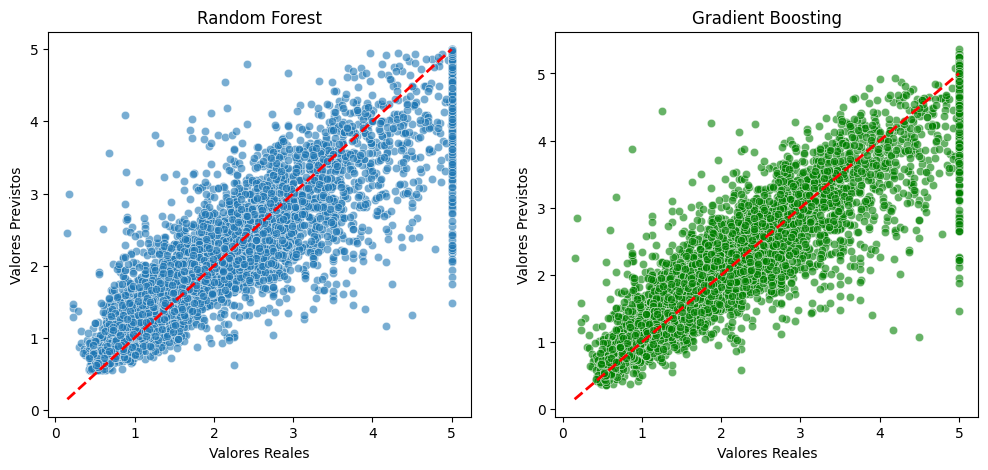

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Cargar el conjunto de datos
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['PRICE'] = california.target

# Dividir los datos en entrenamiento y prueba
X = df.drop('PRICE', axis=1)
y = df['PRICE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y entrenar los modelos ensemble (Ensamblados)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Realizar previsiones
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Evaluar los modelos
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Exhibir métricas
print(f"Random Forest - MSE: {mse_rf:.2f}, R²: {r2_rf:.2f}")
print(f"Gradient Boosting - MSE: {mse_gb:.2f}, R²: {r2_gb:.2f}")

# Visualizar los resultados
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Previstos")
plt.title("Random Forest")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_gb, alpha=0.6, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Previstos")
plt.title("Gradient Boosting")

plt.show()

Son resultados que parecen iguales pero el Gradient Boosting Regressor optimiza aún más los parámetros y combina varios modelos. La diferencia de desempeño entre ambos es pequeña pero para determinar cuál de los modelos de Ensemble es necesario o si es posible resolverlo con otro modelo más sencillo.

Para este caso ninguno de los dos modelos fue el más adecuado para el ejemplo. Así como está ese modelado se evidencia que aún hay mucho que priorizar y mejorar.

# **Clase 3**

## **Aprendizaje No Supervisado - Clustering**

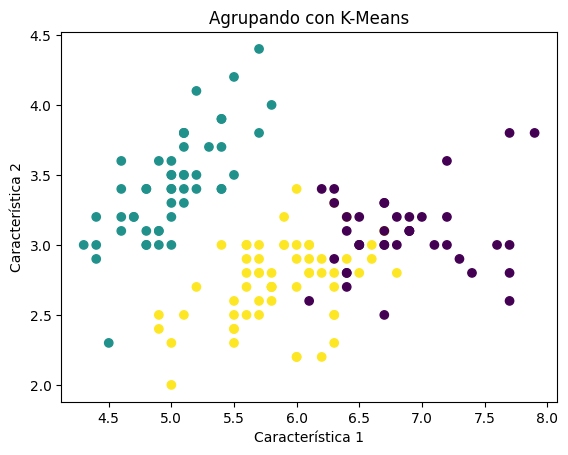

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Cargar Dataset
iris = load_iris()
X = iris.data

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# Visualizar los clusters
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.title("Agrupando con K-Means")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

La cluisterización básicamente se basa en saber en las categorias diferentes qué tan lejanas están entre sí y las de la misma categoría qué tan cercanas están entre sí mismas.

El algoritmo de K-means consiste en tomar promedios. Arroja de forma aleatoria puntos llamados centroides y comienza a medir con las observaciones cercanas con la finalidad de ajustar la distancia e ir desplazando. Con eso calcula el promedio y en base a dicho promedio ajusta la posición del centroide, eso provocará que otros puntos se acerquen a dicho centroide o a otro. Así hasta que se estabilicen para poder visualizar el patrón generado basado en los centroides.  

Hay un algoritmo de Clusterización basado en densidad como *DBSCAN* donde se les da el parámetro de radio, arroja un punto y busca la densidad que esté dentro de ese rango y cuando no encuentra más lanza otro punto o centroide y sigue buscando. Es como un algoritmo de descarte.

Cuando no sé sabe cuál es la mejor cantidad de clústers. Qué recursos se pueden utilizar?

## **Dendrograma - Un Agrupamiento Jerárquico**

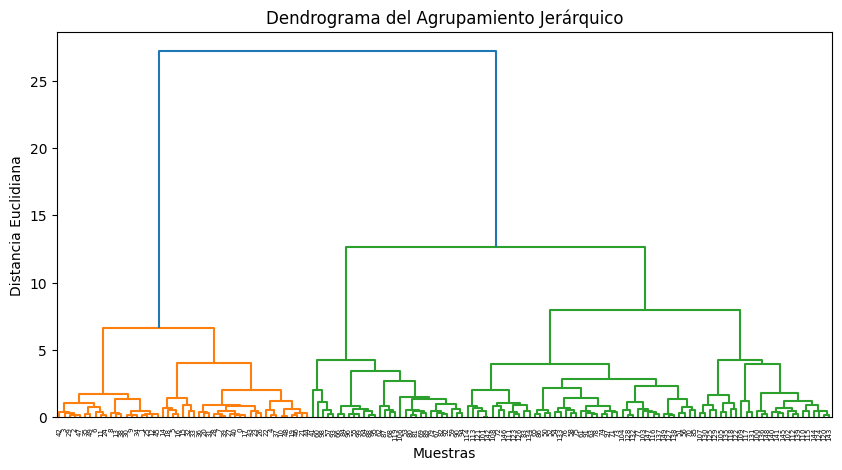

In [ ]:
from sklearn.datasets import load_iris
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Cargar el dataset Iris
iris = load_iris()
X = iris.data

# Normalizar los datos para mejorar el desempeño del clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear el dendrograma
plt.figure(figsize=(10, 5))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrograma del Agrupamiento Jerárquico")
plt.xlabel("Muestras")
plt.ylabel("Distancia Euclidiana")
plt.show()

### **Algoritmo de Aglomeración Jerárquica**

Basado en el Dendrograma ya sabemos que podemos tener 3 grupos.

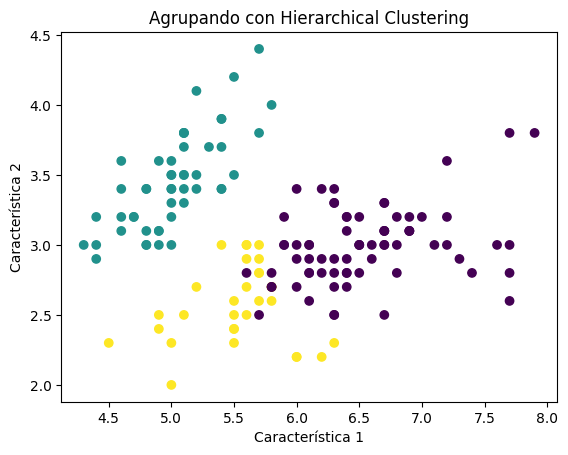

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Aplicar Hierarchical Clustering definiendo 3 grupos
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters = hc.fit_predict(X_scaled)

# Visualizar los clusters
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.title("Agrupando con Hierarchical Clustering")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

## **Aprendizaje no supervisado - PCA (Principal Components Analysis)**

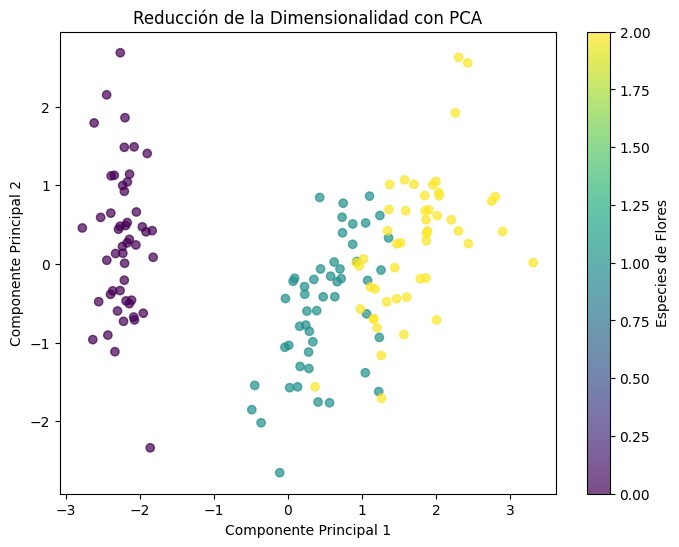

In [ ]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target  # Etiquetas de las especies de flores

# Normalizar los datos para mejorar el desempeño
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA para reducir de 4 a dos dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar los datos reducidos
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Reducción de la Dimensionalidad con PCA")
plt.colorbar(label="Especies de Flores")
plt.show()

In [ ]:
print(pca.explained_variance_ratio_)
print(f"Varianza acumulada: {sum(pca.explained_variance_ratio_):.2f}")

[0.72962445 0.22850762]
Varianza acumulada: 0.96


Con la disminución a la mitad todavía es posible identificar el 96% de la información. Si aún retengo toda esa información entonces se evidencia que es muy útil. Esta técnica de PCA puede ser una alternativa para saber los principales atributes que debemos retener para minimizar la pérdida de información.


# **Clase 4**

## **Procesamiento de imágenes**

## **Redes Neuronales Convolucionales**

Una convolución se podría entender como: Tomar la imagen, se le aplica un filtro para hacerla más nítida o más borrosa y eso es lo que se retiene. Al hacer eso se está haciendo una convolución.

Se compone de muchas capas, capas tras capas. Capas convolucionales, capas de pooling y capas completamente conectadas que es donde está la salida.

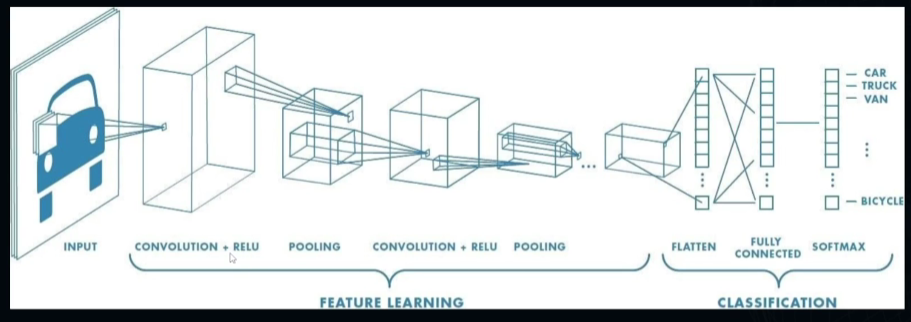


***Convolucional:*** Busca las formas simples: líneas, puntos, bordes, etc.

***Pooling:*** Retiene lo más importante, reduce el tamaño y solo deja lo necesario para reconocerlo posteriormente.

*Más capas convolucionales y más capas de pooling*

***Flatten:*** Vectoriza toda la información.

***Fully-Connected:*** Es donde se determina la salida para la respectiva clasificación.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Realizar upload de la Imagen
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Cargar la imagen en escala de grises
imagen = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Mostrar la imagen original y la matriz correspondiente
plt.figure(figsize=(15,8))

plt.subplot(1, 2, 1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen en tonos de gris")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagen, cmap="gray")
plt.title("Matriz de Pixeles")
for i in range(0, imagen.shape[0], 30):
    for j in range(0, imagen.shape[1], 30):
        plt.text(j, i, str(imagen[i, j]), color="red", fontsize=6, ha='center', va='center')

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Crear un modelo CNN simple
modelo = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),  # Capa convolucional
    MaxPooling2D(pool_size=(2,2)),  # Capa de pooling
    Flatten(),  # Aplanando para la capa densa
    Dense(128, activation='relu'),  # Capa totalmente conectada
    Dense(3, activation='softmax')  # Salida para 3 clases
])
modelo.summary()  # Exhibe la arquitectura de la red

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,936,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,937,667 (15.02 MB)

 Trainable params: 3,937,667 (15.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np
import cv2
from google.colab import files
from PIL import Image

# Hacer la carga de la imagen
uploaded = files.upload()
imagen_path = list(uploaded.keys())[0]  # Toma el nombre del archivo enviado

# Cargar la imagen usando OpenCV
imagen = cv2.imread(imagen_path)
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

# Cargar el modelo MobileNetV2 pre-entrenado
modelo = MobileNetV2(weights="imagenet")

# Pre-procesar la imagen para el formato esperado por el modelo
imagen_redimensionada = cv2.resize(imagen_rgb, (224, 224))
imagen_array = np.expand_dims(imagen_redimensionada, axis=0)
imagen_array = preprocess_input(imagen_array)

# hacer el pronóstico
previsiones = modelo.predict(imagen_array)
label = decode_predictions(previsiones)
print("Objeto identificado:", label[0][0][1])  # Exhibe la clase identificada

### **Principales bibliotecas que se utilizan**

- **OpenCV:** La biblioteca más popular para el procesamiento de imágenes y videos, ofreciendo una amplia gama de funciones para análisis de imágenes, reconocimiento de objetos y computación visual.

- **TensorFlow y PyTorch:** Bibliotecas de aprendizaje profundo, ampliamente utilizadas en visión computacional para el entrenamiento de redes neuronales convolucionales (CNNs) que detectan patrones y características complejas en imágenes.

- **Keras:** Interfaz de alto nivel para la construcción y entrenamiento de redes neuronales, con integración con TensorFlow y enfoque en redes para visión computacional.

### **Proceso de entrenamiento de algoritmos para visión computacional**

- Recolección de datos: Imágenes etiquetadas (con información sobre lo que representan) son esenciales para entrenar modelos precisos.

- Preprocesamiento de datos: Las imágenes pueden necesitar ajustes, como redimensionamiento, normalización y aumento (aumentar la variedad de datos para evitar el sobreajuste).

- Desarrollo del modelo: Redes neuronales convolucionales (CNNs) son comúnmente utilizadas, ya que son efectivas para extraer características jerárquicas de las imágenes, como bordes, formas y texturas.

- Entrenamiento: El modelo se entrena en un conjunto de datos de imágenes para aprender a identificar patrones. Durante el entrenamiento, la red ajusta sus pesos para minimizar los errores de predicción.

- Evaluación y ajuste: Después del entrenamiento, el modelo se prueba en nuevos datos para verificar su precisión. Si es necesario, se realizan ajustes para mejorar su rendimiento.

## **Procesamiento de Lenguaje Natural - NLP**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Conjunto de frases
frases = ["Yo amo viajar para Japón", "Viajar es increíble", "Quiero conocer Japón"]

# Creando el modelo BoW - Bag of Words
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(frases)

# Exhibir matriz resultante
print(vectorizer.get_feature_names_out())
print(X.toarray())

### **Trabajando con Transformers**

In [ ]:
from transformers import pipeline

# Cargar un modelo de generación de texto
generador = pipeline("text-generation", model="gpt2")

# Definir el prompt
prompt = "Cuál es la mejor época para visitar Japón?"

# Generar una respuesta ajustando los parámetros para evitar repeticiones
respuesta = generador(
    prompt,
    max_length=50,      # Aumentar un poco la longitud
    temperature=0.1,    # Controla la aleatoriedad
    top_p=0.9,          # Realiza el muestreo con un núcleo (nucleus sampling)
    top_k=10,           # Restringe la elección al top 50 de palabras con mayor probabilidad
    repetition_penalty=1.2 # Penaliza repeticiones
)

# Exhibir la respuesta formateada
print(respuesta[0]['generated_text'])

# Aprendizaje por Refuerzo

## Identificando Objetos con MobileNetV2

In [5]:
import numpy as np
import gymnasium as gym

# Inicializar el entorno FrozenLake
# El agente necesita cruzar un lago congelado sin caer en los agujeros
env = gym.make("FrozenLake-v1", is_slippery=True)

# Definir los hiperparámetros del Q-Learning
alpha = 0.8  # Tasa de aprendizaje: cuánto aprende el agente de nueva información
gamma = 0.95  # Factor de descuento: cuán importantes son las recompensas futuras en comparación con las inmediatas
epsilon = 1.0  # Probabilidad inicial de explorar acciones aleatorias
epsilon_decay = 0.999  # Reduce gradualmente la exploración a medida que el agente aprende
epsilon_min = 0.01  # Límite mínimo de exploración para garantizar que el agente aún explore un poco
num_episodes = 20000  # Número total de intentos de aprendizaje (episodios)

# Crear la tabla Q (Q-table) con ceros
# Las filas representan los estados y las columnas representan las acciones
q_table = np.zeros((env.observation_space.n, env.action_space.n))

# Iniciar el entrenamiento del agente
for episode in range(num_episodes):
    # Reiniciar el entorno en cada episodio
    state, _ = env.reset()
    done = False

    while not done:
        # Elegir una acción usando la estrategia epsilon-greedy
        # Con probabilidad 'epsilon', elegimos una acción aleatoria (exploración)
        # De lo contrario, elegimos la mejor acción conocida hasta el momento (explotación)
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Explorar una acción aleatoria
        else:
            action = np.argmax(q_table[state])  # Explorar la acción con mayor valor en la Q-table

        # Ejecutar la acción elegida en el entorno
        next_state, reward, done, truncated, _ = env.step(action)

        # Actualizar la Q-table con la fórmula de aprendizaje por refuerzo
        # Q(s, a) = Q(s, a) + alpha * (recompensa + descuento * max(Q(s', a')) - Q(s, a))
        best_next_action = np.max(q_table[next_state])  # Mejor acción en el siguiente estado
        q_table[state, action] += alpha * (reward + gamma * best_next_action - q_table[state, action])

        # Avanzar al siguiente estado
        state = next_state

    # Reducir la tasa de exploración gradualmente, sin superar el mínimo definido
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

# Evaluar el rendimiento del agente entrenado
# Aquí, probamos 1000 episodios para verificar cuántas veces logra cruzar el lago con éxito
successes = 0
for episode in range(1000):
    state, _ = env.reset()
    done = False
    while not done:
        # El agente ahora solo elige la mejor acción aprendida (sin exploración aleatoria)
        action = np.argmax(q_table[state])
        state, reward, done, truncated, _ = env.step(action)
        if done and reward == 1.0:
            successes += 1  # Contabilizar los éxitos

# Mostrar el resultado final
print(f"El agente logró cruzar el lago con éxito en {successes} de 1000 episodios.")

El agente logró cruzar el lago con éxito en 825 de 1000 episodios.
